# From Pilot to Payoff - 04: Q3 - Firm-Level Drivers of Advanced Adoption

Q3: After controlling for country/region context, industry, company size, and time, which representative firm-level drivers from capability, investment, and governance/risk blocks are most strongly associated with advanced AI adoption after checking multicollinearity and model contribution?

### Q3 - Firm-Level Drivers of Advanced Adoption

This section answers Q3: controlling for country, industry, company size, and time, which firm-level driver block - capability, investment, or governance/risk - is most strongly associated with advanced AI adoption? We first check multicollinearity among the drivers with VIF, then fit a standardised nested logistic regression that adds each block in turn (to see which block improves model fit the most), and finally read standardised odds ratios from the full model to compare individual driver strengths.

Important modelling choices:

- `ai_adoption_rate` is excluded because it is mechanically related to `ai_adoption_stage`.
- `ai_maturity_score` is excluded because it is conceptually too close to adoption maturity.
- `ai_failure_rate` is treated as an implementation-risk outcome in Q5, not as a driver.
- Numeric predictors are standardised, so logistic coefficients are comparable as log-odds changes per one standard deviation.

## Setup and data preparation

Re-runs the shared imports, data loading, feature engineering, and standardisation.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.formula.api import logit
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

# Folder for saving generated figures.
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

In [2]:
company = pd.read_csv('ai_company_adoption.csv')
country_index = pd.read_csv('country_ai_index.csv')
industry_summary = pd.read_csv('ai_industry_summary.csv')

print('Dataset shapes')
print(f'company adoption: {company.shape[0]:,} rows x {company.shape[1]:,} columns')
print(f'country index:    {country_index.shape[0]:,} rows x {country_index.shape[1]:,} columns')
print(f'industry summary: {industry_summary.shape[0]:,} rows x {industry_summary.shape[1]:,} columns')

company.head(3)


Dataset shapes
company adoption: 150,000 rows x 43 columns
country index:    30 rows x 8 columns
industry summary: 9 rows x 8 columns


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation


In [3]:
# Feature engineering and merge.
quarter_map = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
company = company.copy()
company['quarter_num'] = company['quarter'].map(quarter_map)
company['advanced_adoption'] = company['ai_adoption_stage'].isin(['partial', 'full']).astype(int)
company['net_jobs_created'] = company['jobs_created'] - company['jobs_displaced']
company['net_jobs_per_100_employees'] = company['net_jobs_created'] / company['num_employees'] * 100
company['reskilling_rate_per_100_employees'] = company['reskilled_employees'] / company['num_employees'] * 100

# Log transform for the skewed investment variable.
# 780 firms (0.52%) report zero AI investment; np.log1p collapses these to 0, far below the
# positive mass (median log ~10.7), creating an artificial left-skewed spike (skew -2.8) that
# distorts the standardised predictor feeding the Q3 logistic model. Instead, log the positive
# amounts (near-symmetric, skew -0.43) and set the rare zeros to the median log, so they sit at
# the centre rather than forming a distorting tail.
_pos_investment = company['ai_investment_per_employee'] > 0
_log_investment = np.log(company['ai_investment_per_employee'].where(_pos_investment))
company['log_ai_investment_per_employee'] = _log_investment.fillna(_log_investment.median())

country_model = country_index.drop(columns=['region'])
country_model['log_gdp_per_capita'] = np.log1p(country_model['gdp_per_capita'])
country_model['log_ai_patent_filings_2024'] = np.log1p(country_model['ai_patent_filings_2024'])

df = company.merge(country_model, on='country', how='left')

# Latest observation per company for robustness checks.
latest_obs = (df.sort_values(['company_id', 'survey_year', 'quarter_num'])
                .groupby('company_id', as_index=False)
                .tail(1)
                .reset_index(drop=True))

# Digital maturity tertiles for interaction models.
df['digital_maturity_tertile'] = pd.qcut(
    df['digital_maturity_index'], q=3, labels=['Low', 'Medium', 'High']
)
latest_obs['digital_maturity_tertile'] = pd.qcut(
    latest_obs['digital_maturity_index'], q=3, labels=['Low', 'Medium', 'High']
)

merge_check = df[['country', 'digital_maturity_index']].isna().mean().rename('missing_rate')
print(f'Merged modelling data: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
print(f'Latest-company robustness data: {latest_obs.shape[0]:,} rows')
print('\nCountry-index missing check:')
print(merge_check)


Merged modelling data: 150,000 rows x 58 columns
Latest-company robustness data: 10,000 rows

Country-index missing check:
country                   0.0
digital_maturity_index    0.0
Name: missing_rate, dtype: float64


In [4]:
# Standardise numeric predictors used in regression models.
standardise_cols = [
    'ai_training_hours', 'num_ai_tools_used', 'ai_projects_active', 'years_using_ai',
    'ai_budget_percentage', 'log_ai_investment_per_employee',
    'regulatory_compliance_score', 'ai_risk_management_score'
]

for col in standardise_cols:
    mean = df[col].mean()
    std = df[col].std(ddof=0)
    df[f'z_{col}'] = (df[col] - mean) / std
    latest_obs[f'z_{col}'] = (latest_obs[col] - mean) / std

print('Created z-score variables for regression comparability.')


Created z-score variables for regression comparability.


In [5]:
# Helper: variance inflation factor (also used in Q2). Defined here so this module is self-contained.
def compute_vif(data, columns):
    X = data[columns].dropna().copy()
    X_std = pd.DataFrame(StandardScaler().fit_transform(X), columns=columns, index=X.index)
    X_const = sm.add_constant(X_std)
    return (pd.DataFrame({
        'variable': columns,
        'VIF': [variance_inflation_factor(X_const.values, i + 1) for i in range(len(columns))]
    }).sort_values('VIF', ascending=False))

In [6]:
# Multicollinearity check: VIF for the standardised firm-level drivers.
# (Low VIF means the drivers are not redundant, so all can stay in the model.)
firm_driver_cols = [
    'z_ai_training_hours', 'z_num_ai_tools_used', 'z_ai_projects_active', 'z_years_using_ai',
    'z_ai_budget_percentage', 'z_log_ai_investment_per_employee',
    'z_regulatory_compliance_score', 'z_ai_risk_management_score'
]
firm_vif = compute_vif(df, firm_driver_cols)
firm_vif

,variable,VIF
4,z_ai_budget_percentage,1.956550
0,z_ai_training_hours,1.665104
2,z_ai_projects_active,1.450851
1,z_num_ai_tools_used,1.272282
5,z_log_ai_investment_per_employee,1.253606
7,z_ai_risk_management_score,1.248139
3,z_years_using_ai,1.028439
6,z_regulatory_compliance_score,1.000148


In [7]:
# Nested logistic regression using statsmodels for interpretable coefficients, pseudo-R2, AIC and BIC.
control_terms = 'C(country) + C(industry) + C(company_size) + C(survey_year) + C(quarter)'
capability_terms = 'z_ai_training_hours + z_num_ai_tools_used + z_ai_projects_active + z_years_using_ai'
investment_terms = 'z_ai_budget_percentage + z_log_ai_investment_per_employee'
governance_terms = 'z_regulatory_compliance_score + z_ai_risk_management_score + C(data_privacy_level) + C(ai_ethics_committee)'

logit_specs = {
    'M0 Controls only': control_terms,
    'M1 Controls + Capability': control_terms + ' + ' + capability_terms,
    'M2 Controls + Investment': control_terms + ' + ' + investment_terms,
    'M3 Controls + Governance': control_terms + ' + ' + governance_terms,
    'M4 Full driver model': control_terms + ' + ' + capability_terms + ' + ' + investment_terms + ' + ' + governance_terms,
}

logit_rows = []
for name, rhs in logit_specs.items():
    res = logit('advanced_adoption ~ ' + rhs, data=df).fit(method='lbfgs', maxiter=200, disp=False)
    logit_rows.append({
        'model': name,
        'n_parameters': int(res.df_model + 1),
        'McFadden_pseudo_R2': res.prsquared,
        'AIC': res.aic,
        'BIC': res.bic
    })

logit_compare = pd.DataFrame(logit_rows)
logit_compare


,model,n_parameters,McFadden_pseudo_R2,AIC,BIC
0,M0 Controls only,46,0.057538,195314.577364,195770.823331
1,M1 Controls + Capability,50,0.418380,120577.448123,121073.367651
2,M2 Controls + Investment,48,0.333588,138137.433331,138613.516078
3,M3 Controls + Governance,51,0.108390,184791.081436,185296.919355
4,M4 Full driver model,57,0.505499,102545.444297,103110.792560


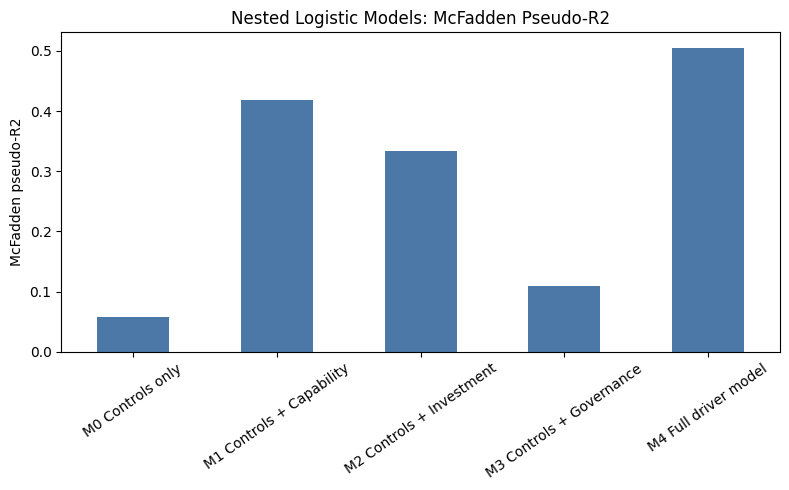

In [8]:
# Visualise how much each block improves model fit (McFadden pseudo-R2).
fig, ax = plt.subplots(figsize=(8, 5))
logit_compare.set_index('model')['McFadden_pseudo_R2'].plot(kind='bar', ax=ax, color='#4c78a8')
ax.set_title('Nested Logistic Models: McFadden Pseudo-R2')
ax.set_ylabel('McFadden pseudo-R2')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_05_logit_model_comparison.png', bbox_inches='tight')
plt.show()

In [9]:
# Odds ratios from the full logistic model (standardised predictors give comparable effect sizes).
full_formula = 'advanced_adoption ~ ' + logit_specs['M4 Full driver model']
logit_full = logit(full_formula, data=df).fit(method='lbfgs', maxiter=200, disp=False)

key_terms = [
    'z_ai_training_hours', 'z_num_ai_tools_used', 'z_ai_projects_active', 'z_years_using_ai',
    'z_ai_budget_percentage', 'z_log_ai_investment_per_employee',
    'z_regulatory_compliance_score', 'z_ai_risk_management_score'
]

or_table = pd.DataFrame({
    'term': key_terms,
    'coef_log_odds': logit_full.params[key_terms],
    'odds_ratio': np.exp(logit_full.params[key_terms]),
    'p_value': logit_full.pvalues[key_terms]
}).reset_index(drop=True)

or_table.sort_values('odds_ratio', ascending=False)


,term,coef_log_odds,odds_ratio,p_value
4,z_ai_budget_percentage,1.499230,4.478239,0.000000
0,z_ai_training_hours,1.290482,3.634538,0.000000
2,z_ai_projects_active,0.769102,2.157828,0.000000
1,z_num_ai_tools_used,0.582356,1.790251,0.000000
3,z_years_using_ai,0.004256,1.004265,0.631522
6,z_regulatory_compliance_score,-0.003522,0.996484,0.703190
5,z_log_ai_investment_per_employee,-0.004083,0.995925,0.653061
7,z_ai_risk_management_score,-0.009685,0.990362,0.333172


**Q3 interpretation.** Capability adds the most explanatory power beyond the controls (McFadden pseudo-R2 rises from 0.06 to 0.42 when the capability block is added), followed by investment (to 0.33); the governance block adds little (to 0.11), and the full model reaches 0.51. In the full model the strongest standardised drivers are `ai_budget_percentage` (OR ~ 4.5) and `ai_training_hours` (OR ~ 3.6), while the governance scores show no independent association (OR ~ 1.0). So **capability and investment - not governance - are the firm-level drivers most associated with advanced adoption.** These are associations, not causal effects, and the large effect sizes partly reflect the simulated structure of the data (advanced adoption is a binning of the underlying adoption rate).